# 11-class Normal Attention vs Differential Attention vs Manual Hybrid

This notebook runs the full 11-class experiment requested:

1. Train **normal attention** on all 11 RadioML2016.10a classes.
2. Train **differential attention** on all 11 classes.
3. Evaluate **manual SNR-aware hybrid**:
   - `SNR <= 0 dB` → differential attention
   - `SNR > 0 dB` → normal attention
4. Plot all three curves together.

No gated SNR model is used in this notebook.

In [1]:
# CELL 1: Setup repo and paths
import os
import sys
import shutil
import subprocess
from pathlib import Path
from datetime import datetime

import pandas as pd
from IPython.display import Image, display, FileLink

os.environ['KERAS_BACKEND'] = 'tensorflow'

REPO_URL = 'https://github.com/akshlabh/amr-5-class.git'
WORK_DIR = Path('/kaggle/working/amr-5-class')

# Full 11-class RadioML2016.10a dataset candidates.
# Edit DATASET manually if your Kaggle input path is different.
DATASET_CANDIDATES = [
    Path('/kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat'),
    Path('/kaggle/input/rml201610a-dict/RML2016.10a_dict.dat'),
    Path('/kaggle/input/radioml2016-10a/RML2016.10a_dict.pkl'),
    Path('/kaggle/input/radioml2016-10a/RML2016.10a_dict.dat'),
    Path('data/RML2016.10a_dict.pkl'),
    Path('data/RML2016.10a_dict.dat'),
]

def find_attached_repo():
    input_root = Path('/kaggle/input')
    if not input_root.exists():
        return None
    for root in input_root.glob('**'):
        if (root / 'src' / 'train.py').exists() and (root / 'configs').exists():
            return root
    return None

if (Path.cwd() / 'src' / 'train.py').exists():
    WORK_DIR = Path.cwd()
    print('Using current repo:', WORK_DIR)
elif (WORK_DIR / 'src' / 'train.py').exists():
    print('Using existing repo:', WORK_DIR)
else:
    attached = find_attached_repo()
    if attached is not None:
        print('Copying attached repo from:', attached)
        if WORK_DIR.exists():
            shutil.rmtree(WORK_DIR)
        shutil.copytree(attached, WORK_DIR)
    else:
        print('Cloning repo from GitHub...')
        subprocess.run(['git', 'clone', REPO_URL, str(WORK_DIR)], check=True)

os.chdir(WORK_DIR)
if str(WORK_DIR) not in sys.path:
    sys.path.insert(0, str(WORK_DIR))

DATASET = next((p for p in DATASET_CANDIDATES if p.exists()), None)
assert DATASET is not None, 'Dataset not found. Set DATASET manually in this cell.'

NORMAL11_DIR = Path('experiments/11class_attention')
DIFF11_DIR = Path('experiments/11class_diffattention')
HYBRID11_DIR = Path('experiments/11class_manual_hybrid_snr_aware_attention')

print('Working dir:', Path.cwd())
print('Dataset    :', DATASET)
print('Dataset OK :', DATASET.exists())

Cloning repo from GitHub...


Cloning into '/kaggle/working/amr-5-class'...


Working dir: /kaggle/working/amr-5-class
Dataset    : /kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat
Dataset OK : True


In [2]:
# CELL 2: Check required files
required = [
    'configs/exp_11class_attention.yaml',
    'configs/exp_11class_diffattention.yaml',
    'src/train.py',
    'src/evaluate_11class_manual_hybrid_snr_aware_attention.py',
    'src/models/mcldnn_attention.py',
    'src/models/mcldnn_diffattention.py',
    'src/dataset.py',
]

for f in required:
    print(('OK      ' if Path(f).exists() else 'MISSING ') + f)
    assert Path(f).exists(), f'Missing required file: {f}'

normal_weights = NORMAL11_DIR / 'checkpoints/best_model.weights.h5'
diff_weights = DIFF11_DIR / 'checkpoints/best_model.weights.h5'
print('\nNormal weights:', normal_weights, normal_weights.exists())
print('Diff weights  :', diff_weights, diff_weights.exists())

OK      configs/exp_11class_attention.yaml
OK      configs/exp_11class_diffattention.yaml
OK      src/train.py
OK      src/evaluate_11class_manual_hybrid_snr_aware_attention.py
OK      src/models/mcldnn_attention.py
OK      src/models/mcldnn_diffattention.py
OK      src/dataset.py

Normal weights: experiments/11class_attention/checkpoints/best_model.weights.h5 False
Diff weights  : experiments/11class_diffattention/checkpoints/best_model.weights.h5 False


In [3]:
# CELL 3: Train 11-class normal attention first
# Set FORCE_RETRAIN_NORMAL=True if you want a completely fresh run.
FORCE_RETRAIN_NORMAL = True

if FORCE_RETRAIN_NORMAL and NORMAL11_DIR.exists():
    print('Removing old normal 11-class outputs:', NORMAL11_DIR)
    shutil.rmtree(NORMAL11_DIR)

normal_weights = NORMAL11_DIR / 'checkpoints/best_model.weights.h5'
if normal_weights.exists():
    print('Normal 11-class attention checkpoint already exists, skipping training.')
else:
    cmd = [
        sys.executable, '-u', 'src/train.py',
        '--config', 'configs/exp_11class_attention.yaml',
        '--datasetpath', str(DATASET),
    ]
    print('Running:', ' '.join(cmd))
    process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in process.stdout:
        print(line, end='', flush=True)
    rc = process.wait()
    if rc != 0:
        raise subprocess.CalledProcessError(rc, process.args)

assert normal_weights.exists(), f'Missing normal attention weights: {normal_weights}'
print('Normal 11-class attention training complete.')

Running: /usr/bin/python3 -u src/train.py --config configs/exp_11class_attention.yaml --datasetpath /kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat
[seed] All seeds fixed to 2016  (Python, NumPy, TensorFlow 2.20.0)

  Experiment : 11class_attention
  Model      : mcldnn_attention
  Branch     : full
  Dropout    : 0.6
  L2 Dense   : 0.001   L2 LSTM : 0.0001
  SNR Weighted: False
  Initial LR : 0.0005
  SNR Range  : None
  Shuffle Split: False
  Classes    : ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
  n_classes  : 11
  Checkpoint : experiments/11class_attention/checkpoints/best_model.weights.h5

[dataset] Loading 11 classes: ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
[dataset] SNR range: -20 dB to 18 dB  (20 levels)
[dataset] After normalization — train RMS: 1.0000  (should be ≈1.0)
[dataset] Split: 132000 train | 44000 val | 44000 test samples
[train] 

In [4]:
# CELL 4: Train 11-class differential attention second
# Set FORCE_RETRAIN_DIFF=True if you want a completely fresh run.
FORCE_RETRAIN_DIFF = True

if FORCE_RETRAIN_DIFF and DIFF11_DIR.exists():
    print('Removing old diff 11-class outputs:', DIFF11_DIR)
    shutil.rmtree(DIFF11_DIR)

diff_weights = DIFF11_DIR / 'checkpoints/best_model.weights.h5'
if diff_weights.exists():
    print('Diff 11-class attention checkpoint already exists, skipping training.')
else:
    cmd = [
        sys.executable, '-u', 'src/train.py',
        '--config', 'configs/exp_11class_diffattention.yaml',
        '--datasetpath', str(DATASET),
    ]
    print('Running:', ' '.join(cmd))
    process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in process.stdout:
        print(line, end='', flush=True)
    rc = process.wait()
    if rc != 0:
        raise subprocess.CalledProcessError(rc, process.args)

assert diff_weights.exists(), f'Missing diff attention weights: {diff_weights}'
print('Differential 11-class attention training complete.')

Running: /usr/bin/python3 -u src/train.py --config configs/exp_11class_diffattention.yaml --datasetpath /kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat
[seed] All seeds fixed to 2016  (Python, NumPy, TensorFlow 2.20.0)

  Experiment : 11class_diffattention
  Model      : mcldnn_diffattention
  Branch     : full
  Dropout    : 0.5
  L2 Dense   : 0.001   L2 LSTM : 0.0001
  SNR Weighted: False
  Initial LR : 0.0005
  SNR Range  : None
  Shuffle Split: False
  Classes    : ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
  n_classes  : 11
  Checkpoint : experiments/11class_diffattention/checkpoints/best_model.weights.h5

[dataset] Loading 11 classes: ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
[dataset] SNR range: -20 dB to 18 dB  (20 levels)
[dataset] After normalization — train RMS: 1.0000  (should be ≈1.0)
[dataset] Split: 132000 train | 44000 val | 44000 test 

In [5]:
# CELL 5: Evaluate manual SNR-aware hybrid and compare all three curves
# Manual rule: SNR <= 0 dB uses diff attention, SNR > 0 dB uses normal attention.

if HYBRID11_DIR.exists():
    print('Removing old 11-class hybrid outputs:', HYBRID11_DIR)
    shutil.rmtree(HYBRID11_DIR)

cmd = [
    sys.executable, '-u', 'src/evaluate_11class_manual_hybrid_snr_aware_attention.py',
    '--datasetpath', str(DATASET),
    '--normal-weights', str(normal_weights),
    '--diff-weights', str(diff_weights),
    '--output-dir', str(HYBRID11_DIR),
    '--threshold-db', '0',
]
print('Running:', ' '.join(cmd))

process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in process.stdout:
    print(line, end='', flush=True)
rc = process.wait()
if rc != 0:
    raise subprocess.CalledProcessError(rc, process.args)

assert (HYBRID11_DIR / 'results/test_score.csv').exists()
assert (HYBRID11_DIR / 'results/normal_diff_manual_hybrid_acc_per_snr.csv').exists()
print('11-class manual hybrid evaluation complete.')

Running: /usr/bin/python3 -u src/evaluate_11class_manual_hybrid_snr_aware_attention.py --datasetpath /kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat --normal-weights experiments/11class_attention/checkpoints/best_model.weights.h5 --diff-weights experiments/11class_diffattention/checkpoints/best_model.weights.h5 --output-dir experiments/11class_manual_hybrid_snr_aware_attention --threshold-db 0

  Experiment : 11class_manual_hybrid_snr_aware_attention
  Classes    : all 11 RadioML2016.10a classes
  Rule       : SNR <= 0 dB -> diff, else normal
  Normal ckpt: experiments/11class_attention/checkpoints/best_model.weights.h5
  Diff ckpt  : experiments/11class_diffattention/checkpoints/best_model.weights.h5
  Output dir : experiments/11class_manual_hybrid_snr_aware_attention

[dataset] Loading 11 classes: ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
[dataset] SNR range: -20 dB to 18 dB  (20 levels)
[dataset] Afte

Overall test score


,model,loss,accuracy
0,normal_attention,0.981197,0.640909
1,diff_attention,1.138102,0.627955
2,manual_hybrid_snr_aware,1.149593,0.641750


Accuracy by SNR


,snr,n_test,normal_attention_accuracy,diff_attention_accuracy,manual_hybrid_accuracy,manual_hybrid_minus_normal,manual_hybrid_selected_model
0,-20,2200,0.232273,0.207727,0.207727,-0.024545,diff_attention
1,-18,2200,0.277727,0.254091,0.254091,-0.023636,diff_attention
2,-16,2200,0.309545,0.299091,0.299091,-0.010455,diff_attention
3,-14,2200,0.317273,0.328182,0.328182,0.010909,diff_attention
4,-12,2200,0.339091,0.351818,0.351818,0.012727,diff_attention
5,-10,2200,0.350000,0.363182,0.363182,0.013182,diff_attention
6,-8,2200,0.391818,0.392727,0.392727,0.000909,diff_attention
7,-6,2200,0.465455,0.478182,0.478182,0.012727,diff_attention
8,-4,2200,0.603182,0.610455,0.610455,0.007273,diff_attention
9,-2,2200,0.726364,0.733182,0.733182,0.006818,diff_attention


experiments/11class_manual_hybrid_snr_aware_attention/figures/normal_vs_diff_vs_manual_hybrid_acc_vs_snr.png


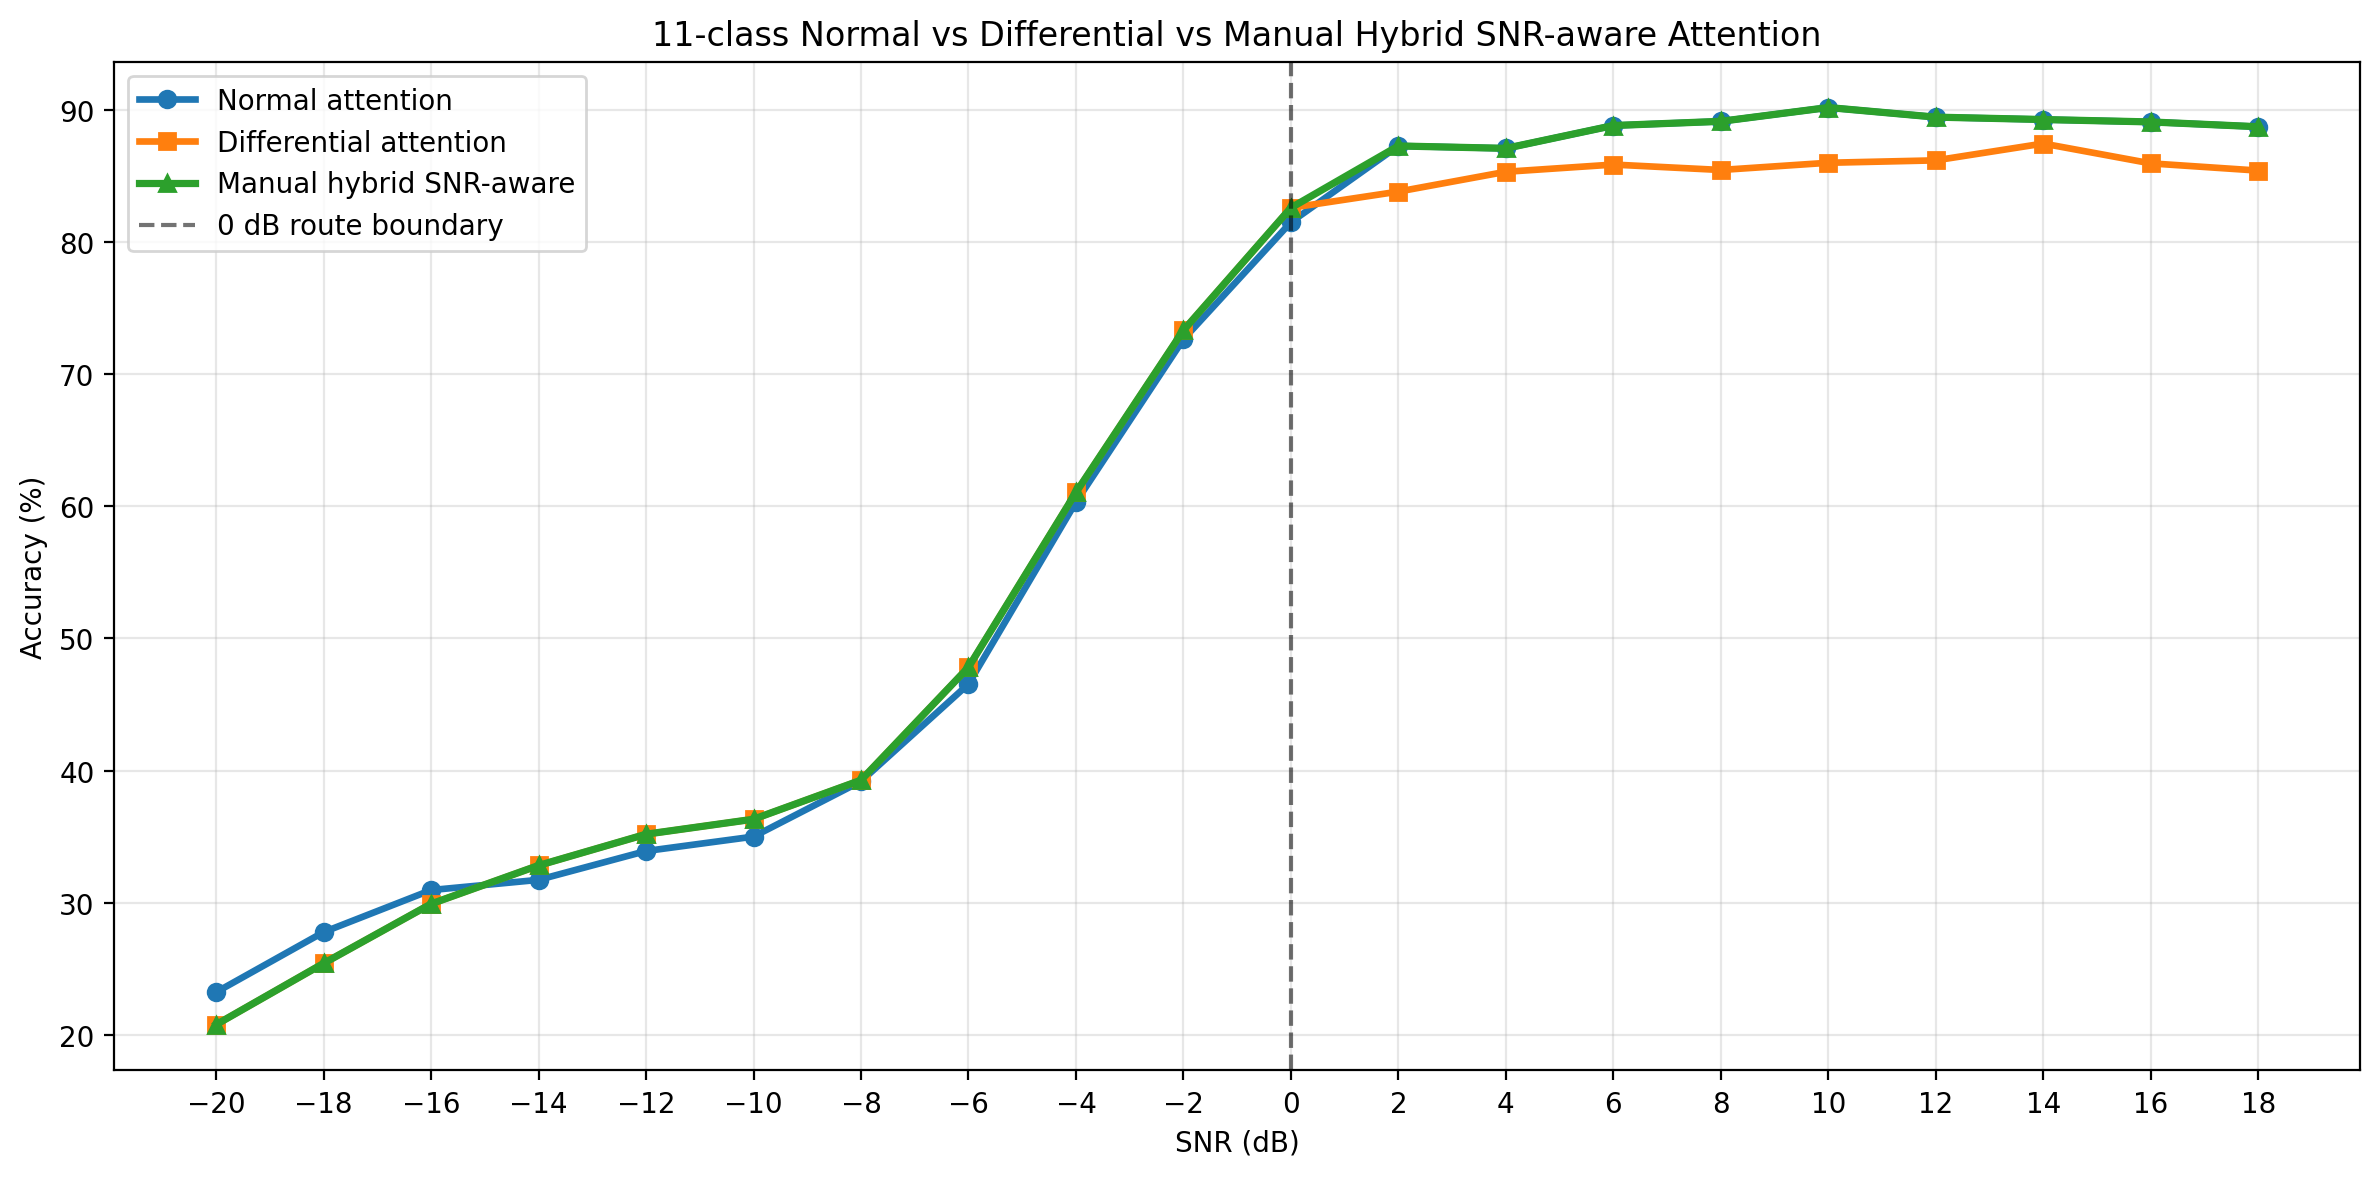

experiments/11class_manual_hybrid_snr_aware_attention/figures/manual_hybrid_minus_normal_delta_by_snr.png


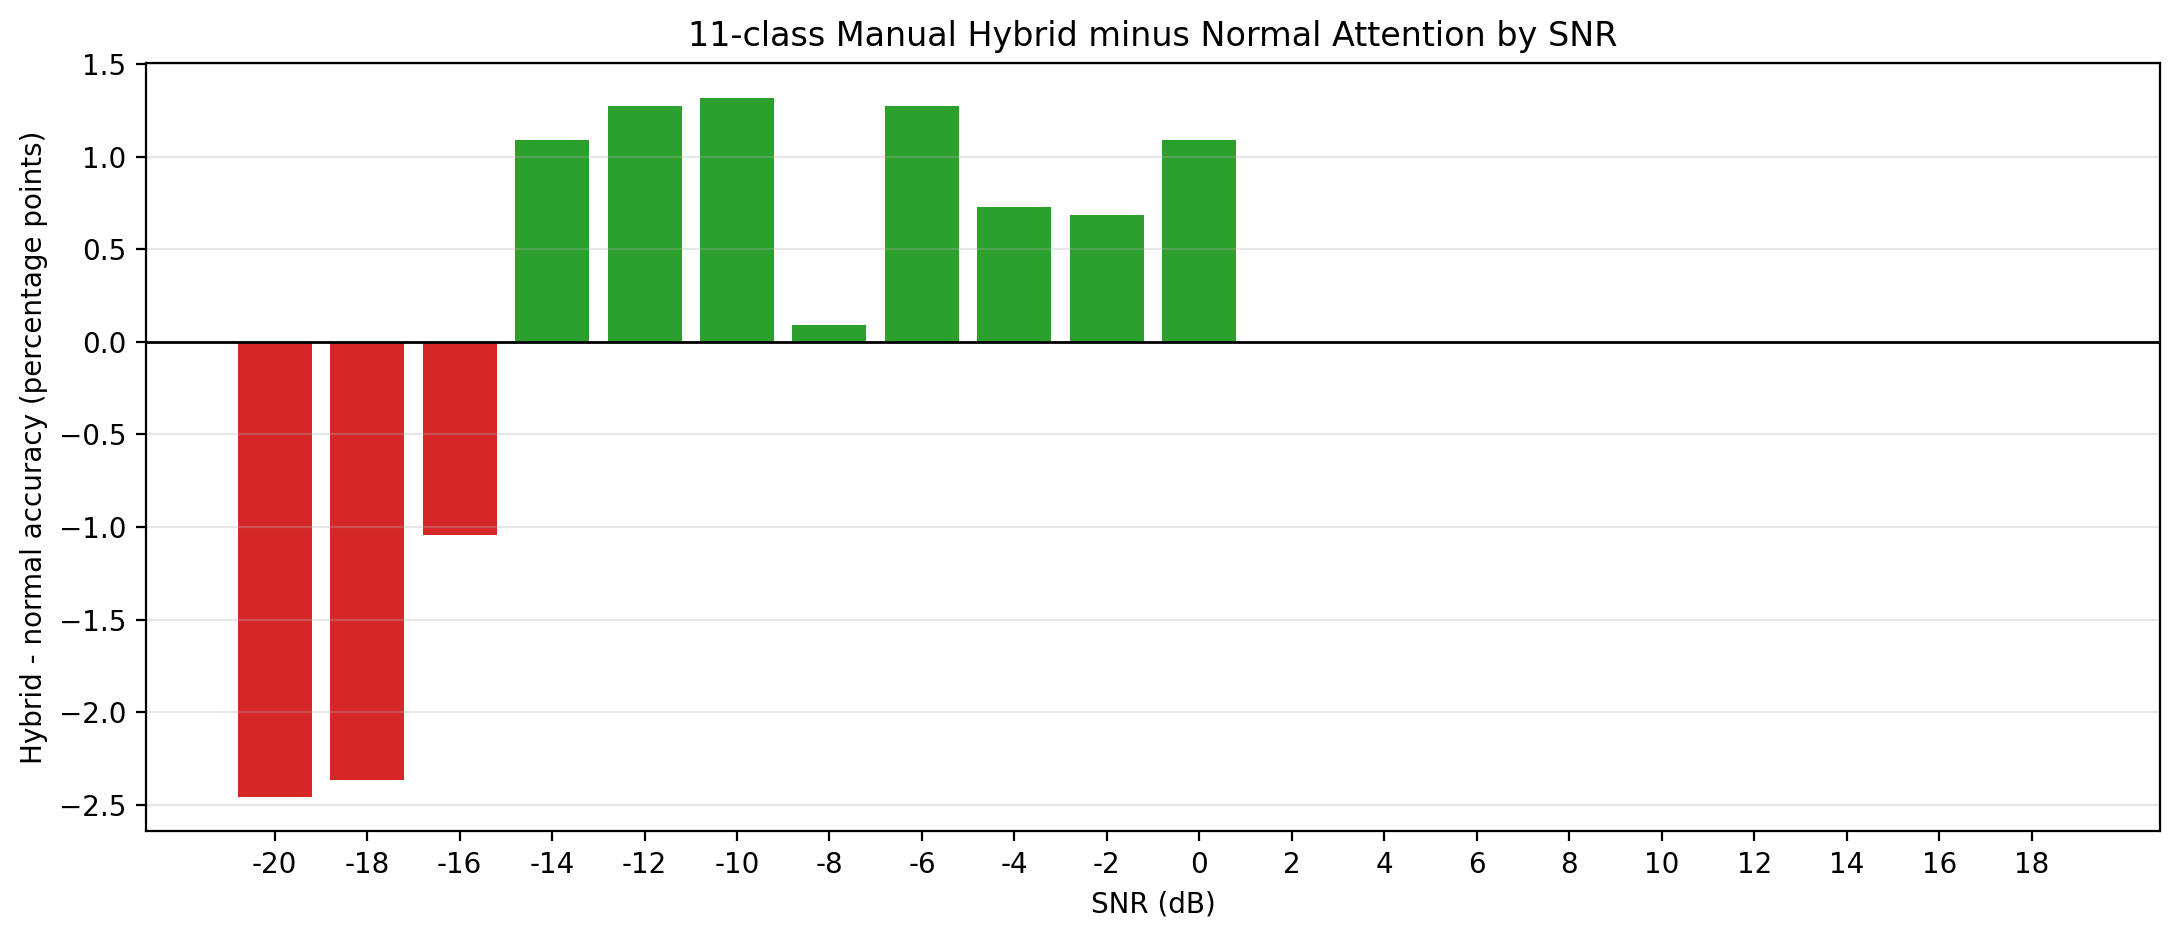

experiments/11class_manual_hybrid_snr_aware_attention/figures/confusion_normal_attention_all_snrs.png


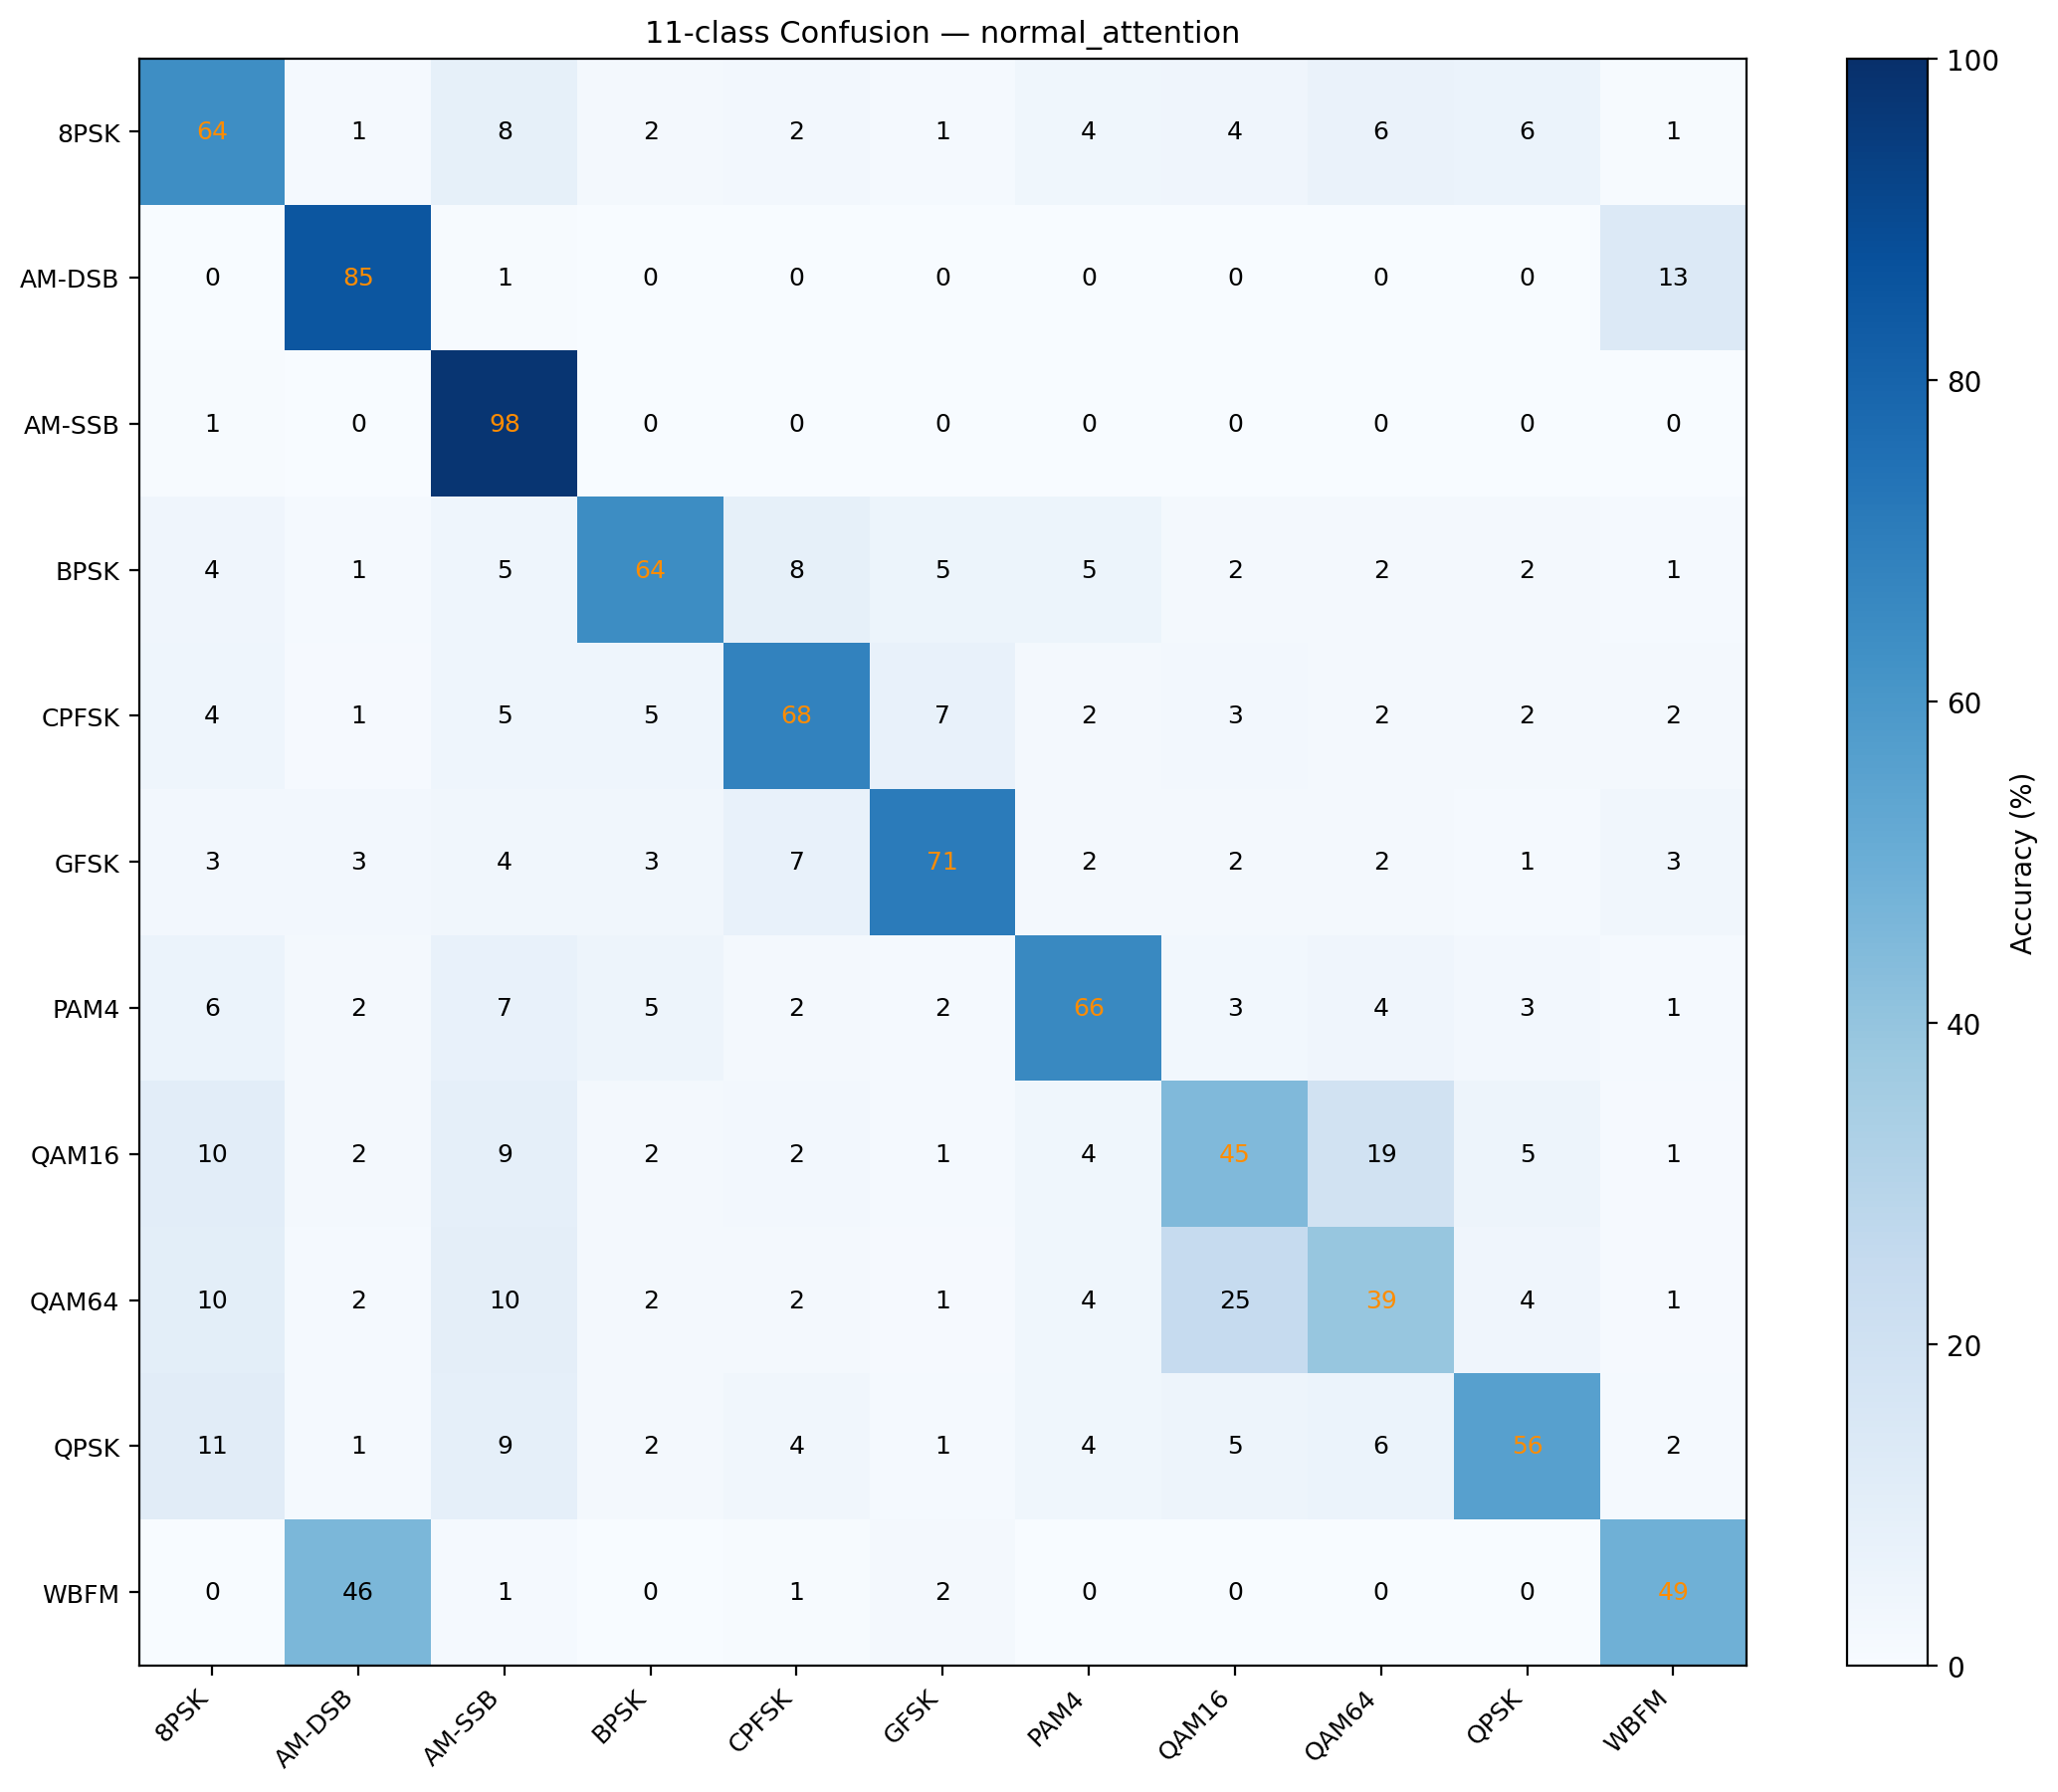

experiments/11class_manual_hybrid_snr_aware_attention/figures/confusion_diff_attention_all_snrs.png


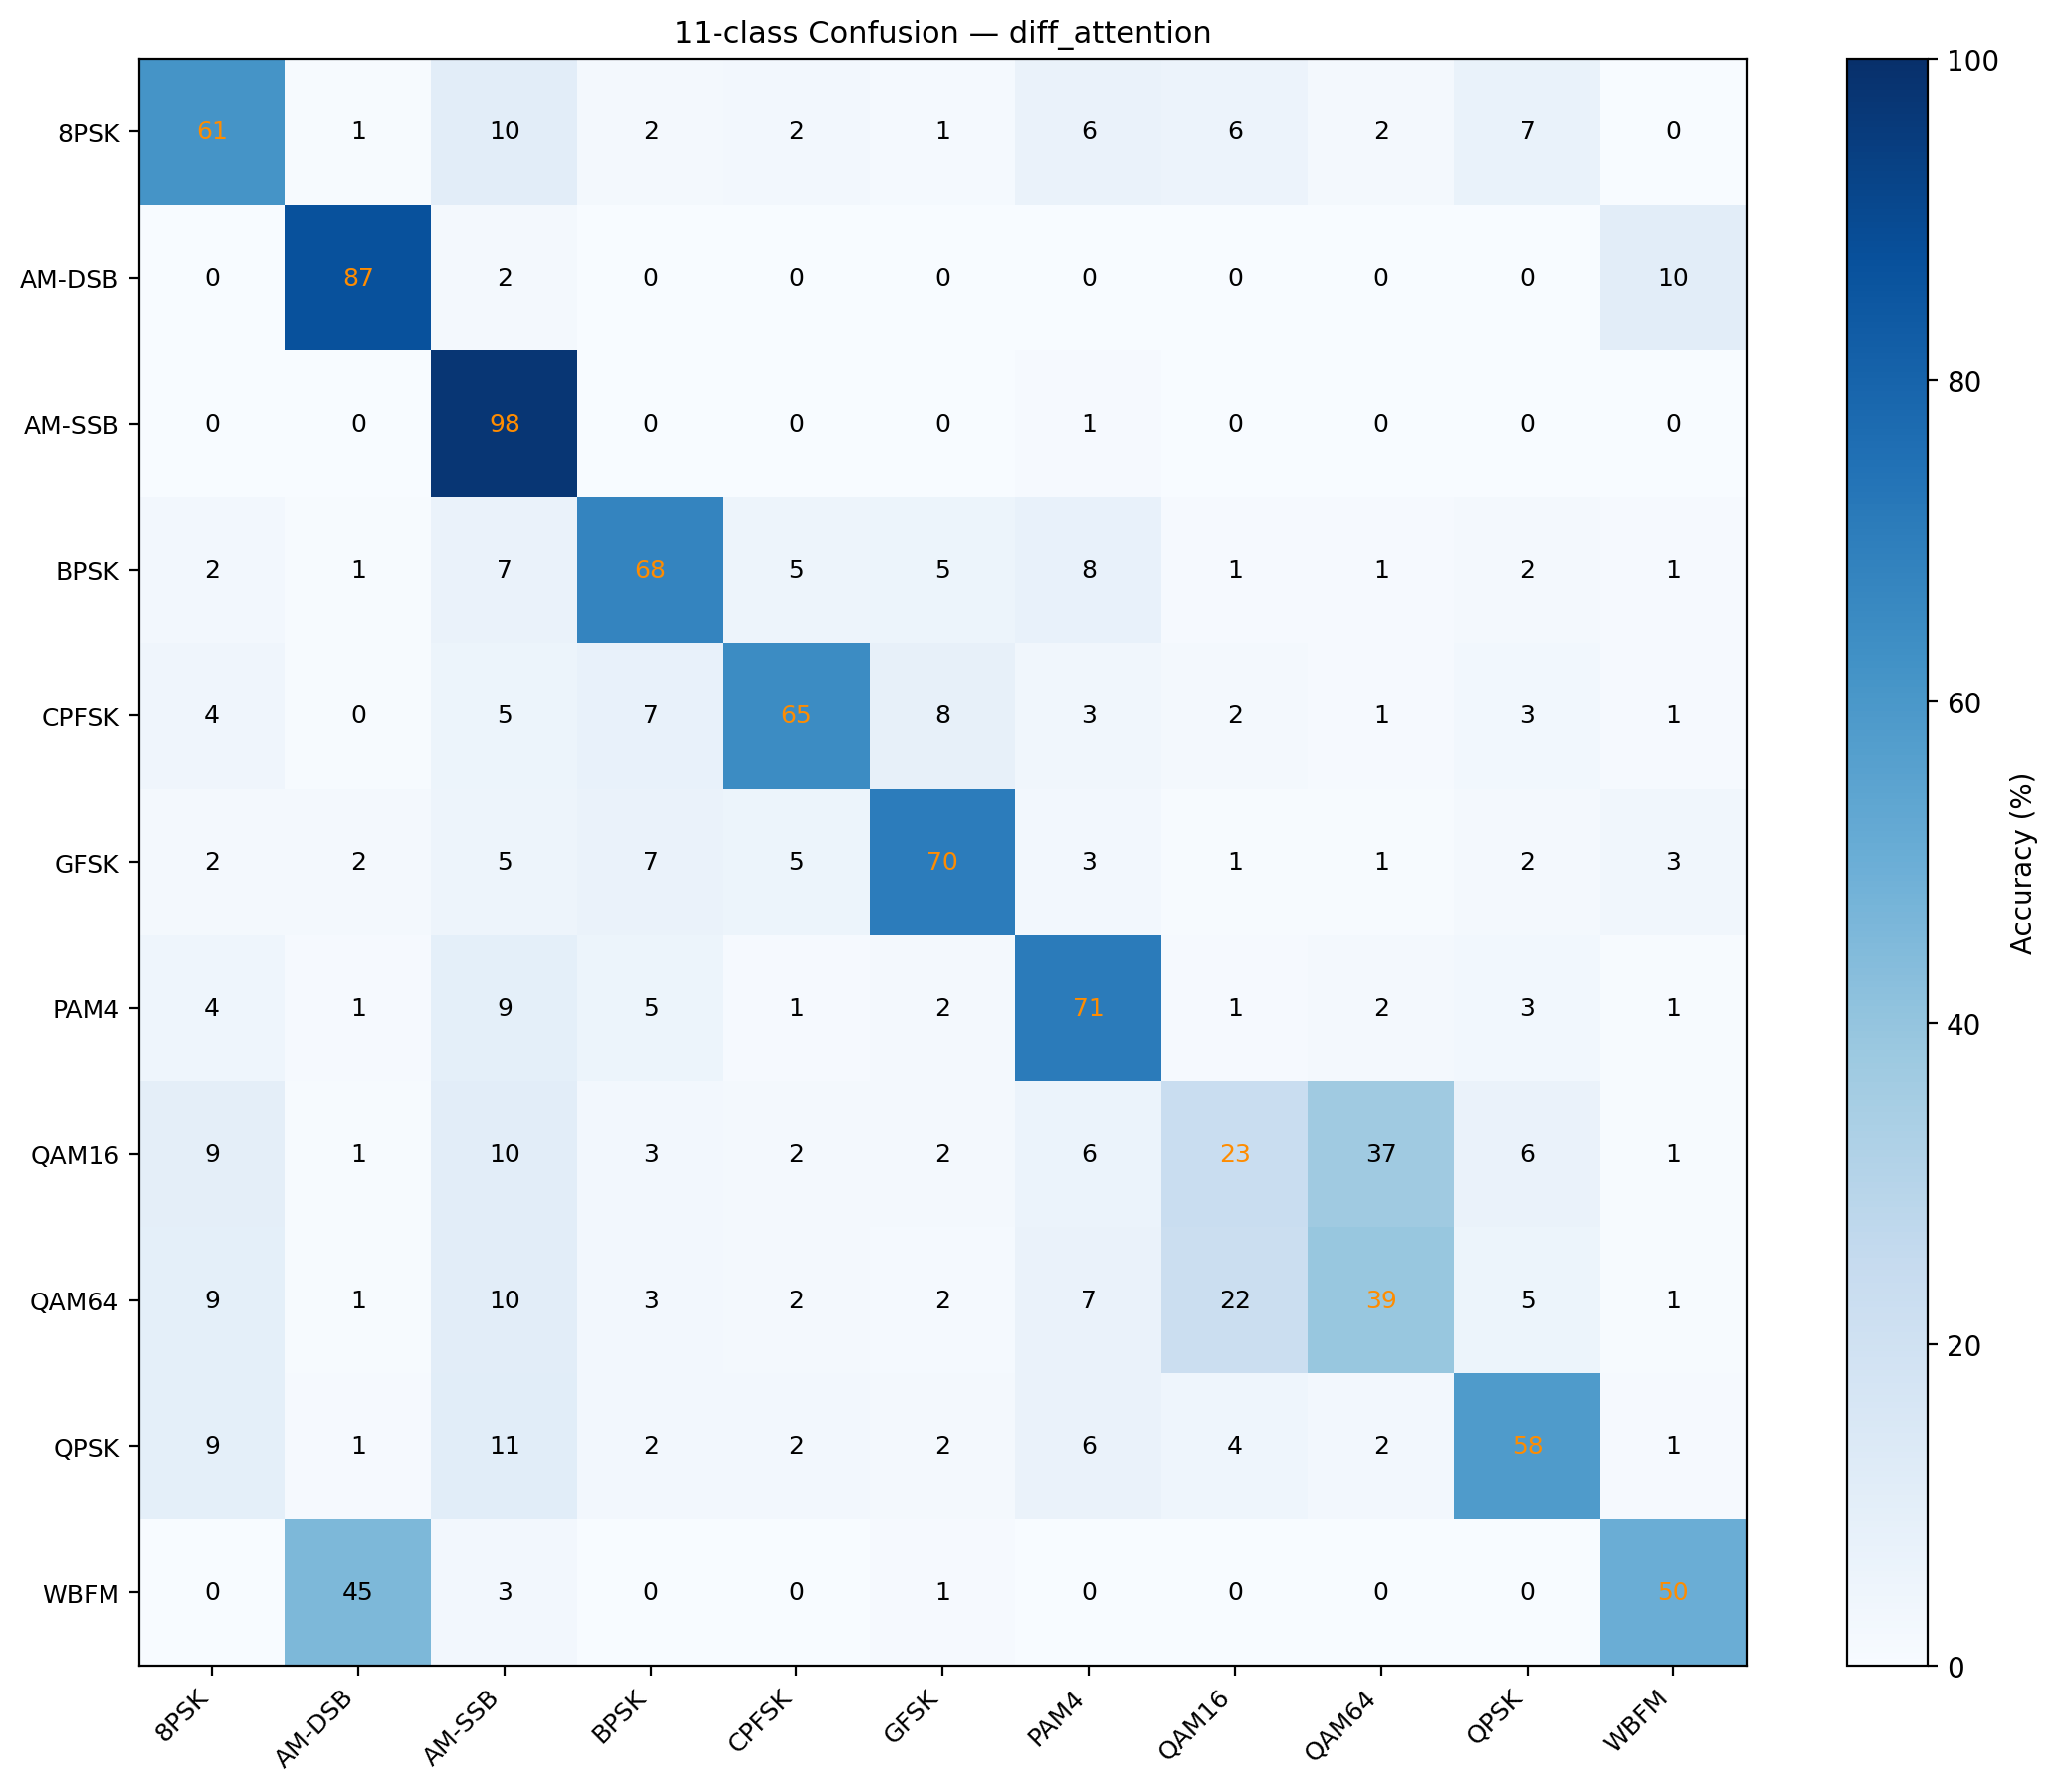

experiments/11class_manual_hybrid_snr_aware_attention/figures/confusion_manual_hybrid_snr_aware_all_snrs.png


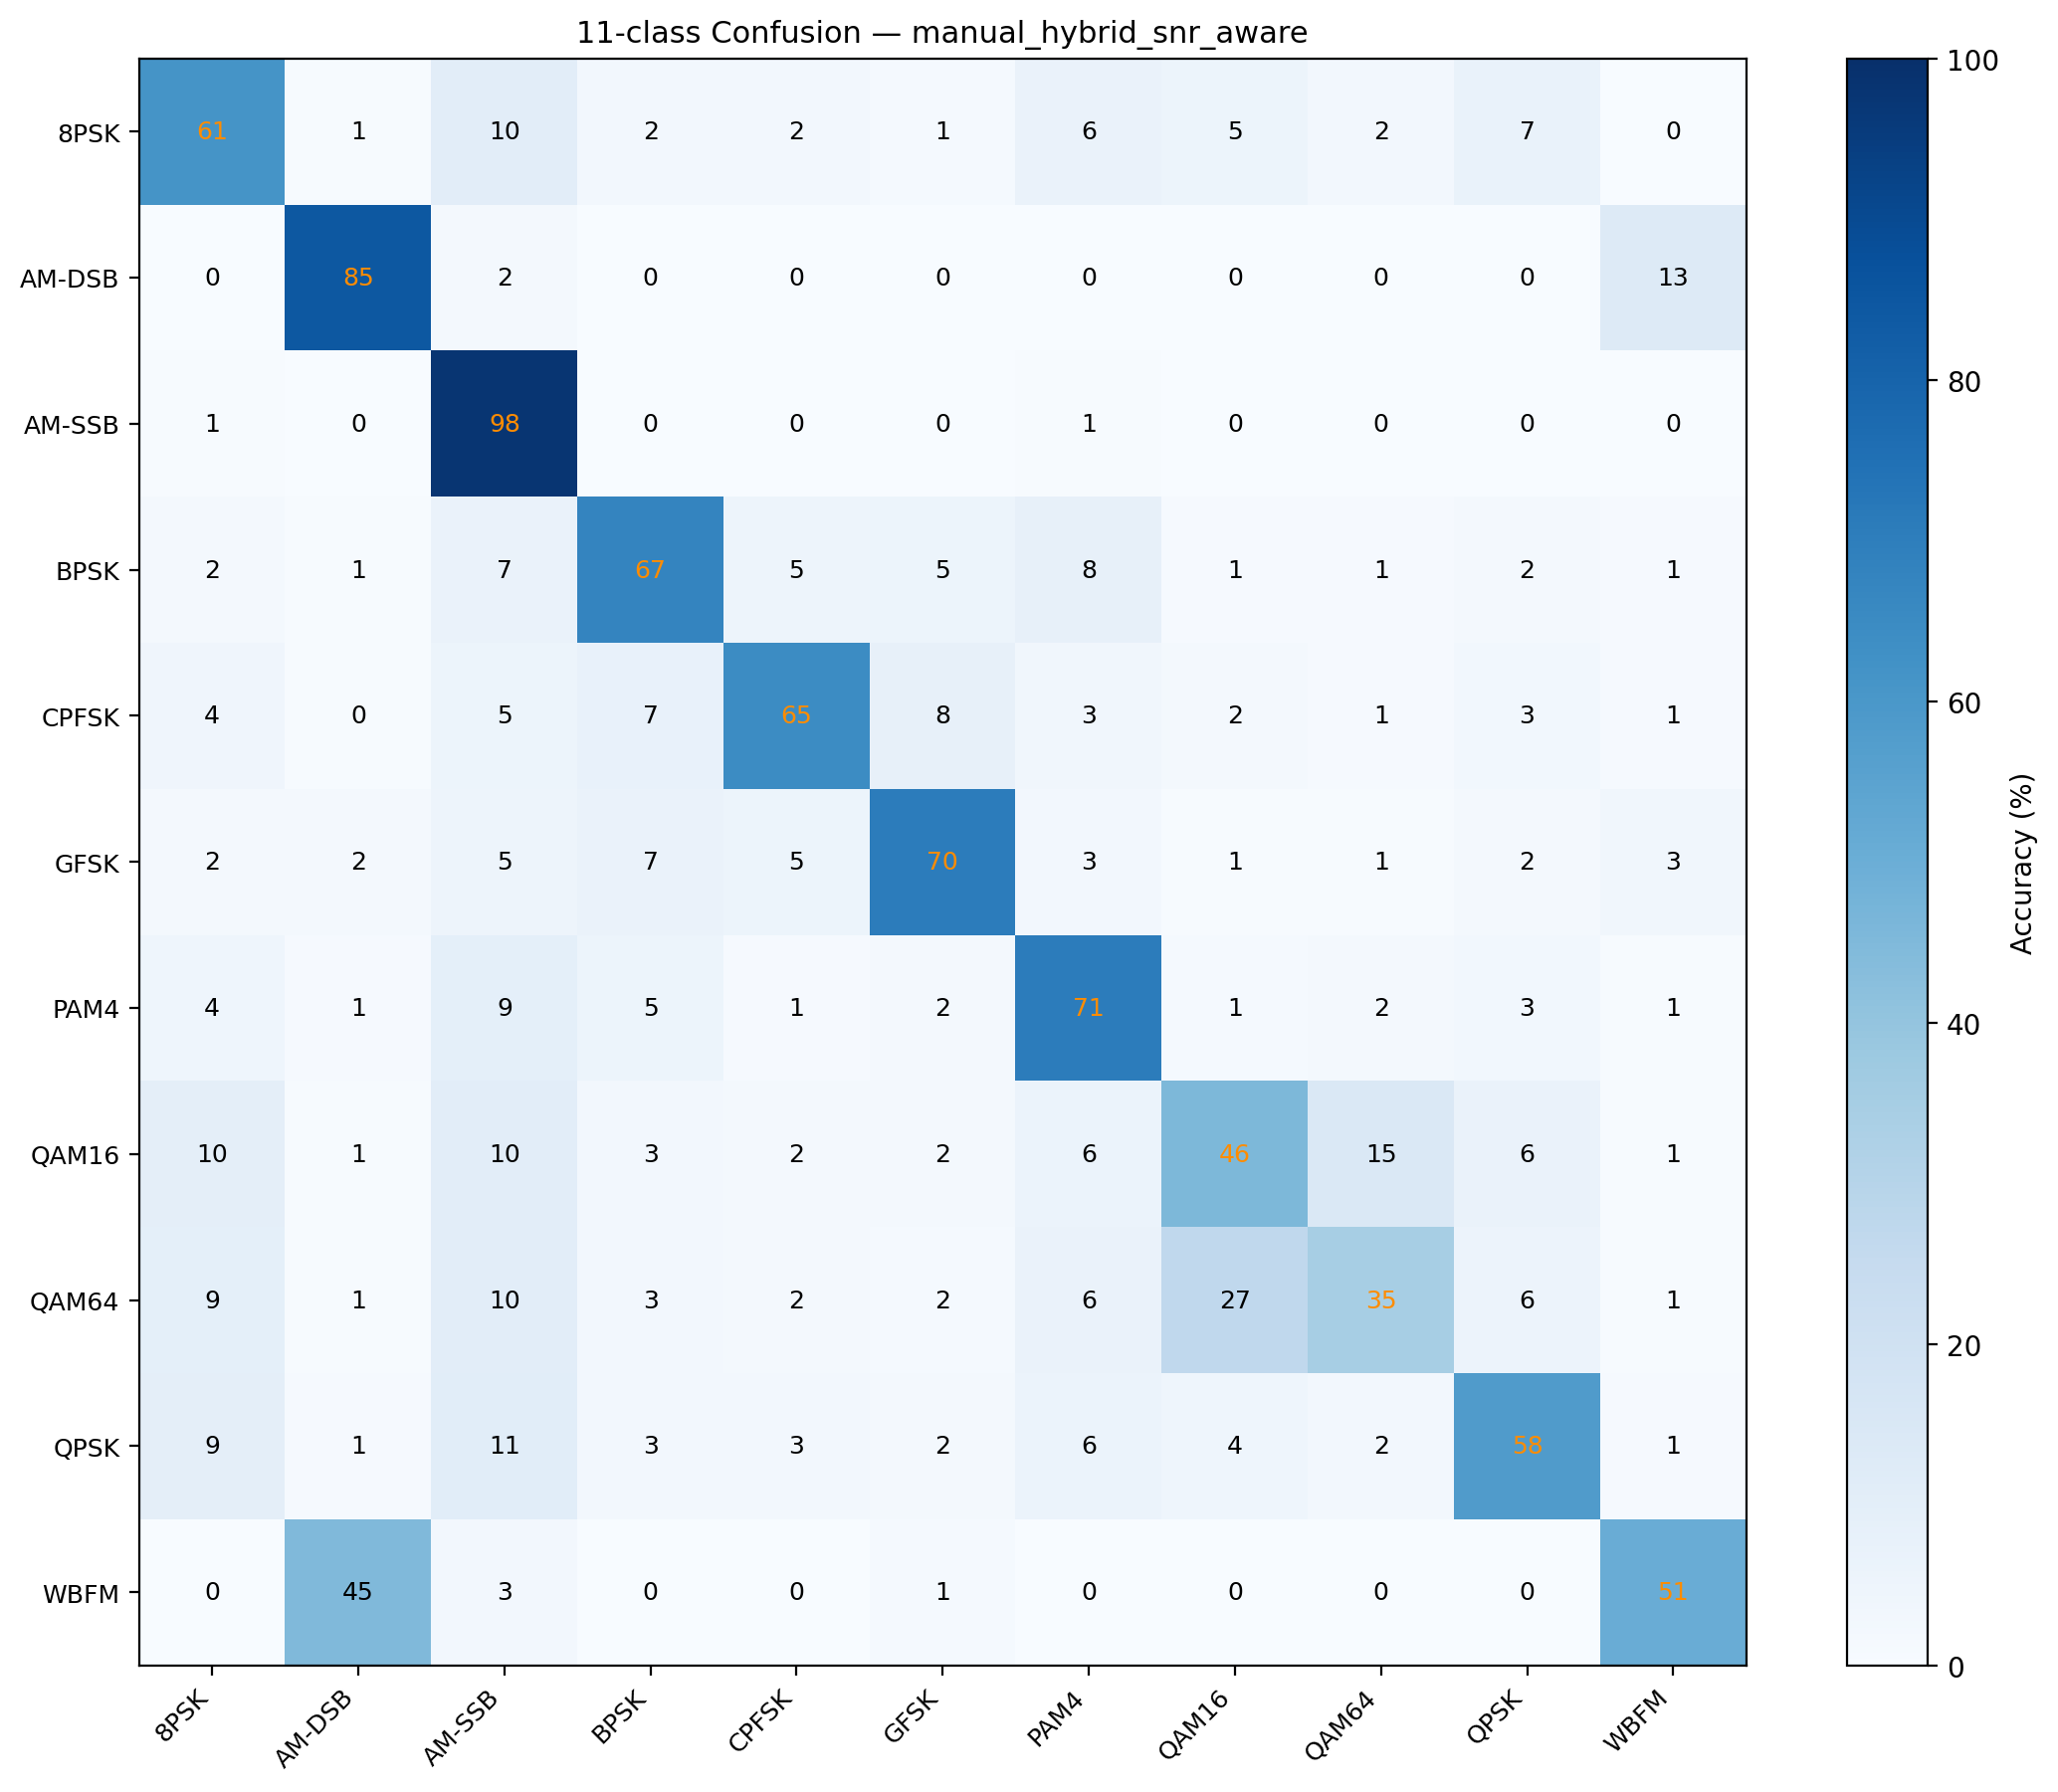

In [6]:
# CELL 6: Display summary tables and plots
score = pd.read_csv(HYBRID11_DIR / 'results/test_score.csv')
per_snr = pd.read_csv(HYBRID11_DIR / 'results/normal_diff_manual_hybrid_acc_per_snr.csv')

print('Overall test score')
display(score)

print('Accuracy by SNR')
display(per_snr)

figs = [
    HYBRID11_DIR / 'figures/normal_vs_diff_vs_manual_hybrid_acc_vs_snr.png',
    HYBRID11_DIR / 'figures/manual_hybrid_minus_normal_delta_by_snr.png',
    HYBRID11_DIR / 'figures/confusion_normal_attention_all_snrs.png',
    HYBRID11_DIR / 'figures/confusion_diff_attention_all_snrs.png',
    HYBRID11_DIR / 'figures/confusion_manual_hybrid_snr_aware_all_snrs.png',
]

for fig in figs:
    print(fig)
    if fig.exists():
        display(Image(filename=str(fig)))
    else:
        print('Missing:', fig)

In [7]:
# CELL 7: Create repo-ready zip with all 11-class experiment outputs
stamp = datetime.now().strftime('%Y%m%d_%H%M')
zip_root = Path('/kaggle/working') / f'11class_attention_diff_manual_hybrid_repo_ready_{stamp}'
stage = Path('/kaggle/working/11class_attention_diff_manual_hybrid_stage')
if stage.exists():
    shutil.rmtree(stage)

for src_dir in [NORMAL11_DIR, DIFF11_DIR, HYBRID11_DIR]:
    dst = stage / 'experiments' / src_dir.name
    print('Copying', src_dir, '->', dst)
    shutil.copytree(src_dir, dst)

zip_path = shutil.make_archive(str(zip_root), 'zip', root_dir=str(stage), base_dir='experiments')
print('Created repo-ready zip:', zip_path)
print('\nExtract this at repo root. It will create/update:')
print('  experiments/11class_attention/')
print('  experiments/11class_diffattention/')
print('  experiments/11class_manual_hybrid_snr_aware_attention/')

display(FileLink(zip_path))

Copying experiments/11class_attention -> /kaggle/working/11class_attention_diff_manual_hybrid_stage/experiments/11class_attention
Copying experiments/11class_diffattention -> /kaggle/working/11class_attention_diff_manual_hybrid_stage/experiments/11class_diffattention
Copying experiments/11class_manual_hybrid_snr_aware_attention -> /kaggle/working/11class_attention_diff_manual_hybrid_stage/experiments/11class_manual_hybrid_snr_aware_attention
Created repo-ready zip: /kaggle/working/11class_attention_diff_manual_hybrid_repo_ready_20260704_2020.zip

Extract this at repo root. It will create/update:
  experiments/11class_attention/
  experiments/11class_diffattention/
  experiments/11class_manual_hybrid_snr_aware_attention/


/kaggle/working/11class_attention_diff_manual_hybrid_repo_ready_20260704_2020.zip